In [2]:
from pathlib import Path
REPO_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "absorption_paper_source_data").is_dir())
import sys
from pathlib import Path

# Explicit project root
project_root = Path(str(REPO_ROOT))

# Add to sys.path if not already present
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"[path] Added project root: {project_root}")
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import pandas as pd
import numpy as np
import torch
# =========================================================
# FORCE ARIAL GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial"
plt.rcParams["mathtext.it"] = "Arial:italic"
plt.rcParams["mathtext.bf"] = "Arial:bold"

import os
import re
import pandas as pd
import numpy as np
import torch

from ase.build import minimize_rotation_and_translation
from ase import Atoms
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

import matplotlib.cm as cm
import matplotlib.colors as mc
import colorsys


[path] Added project root: 


B = 0.5733924329692082


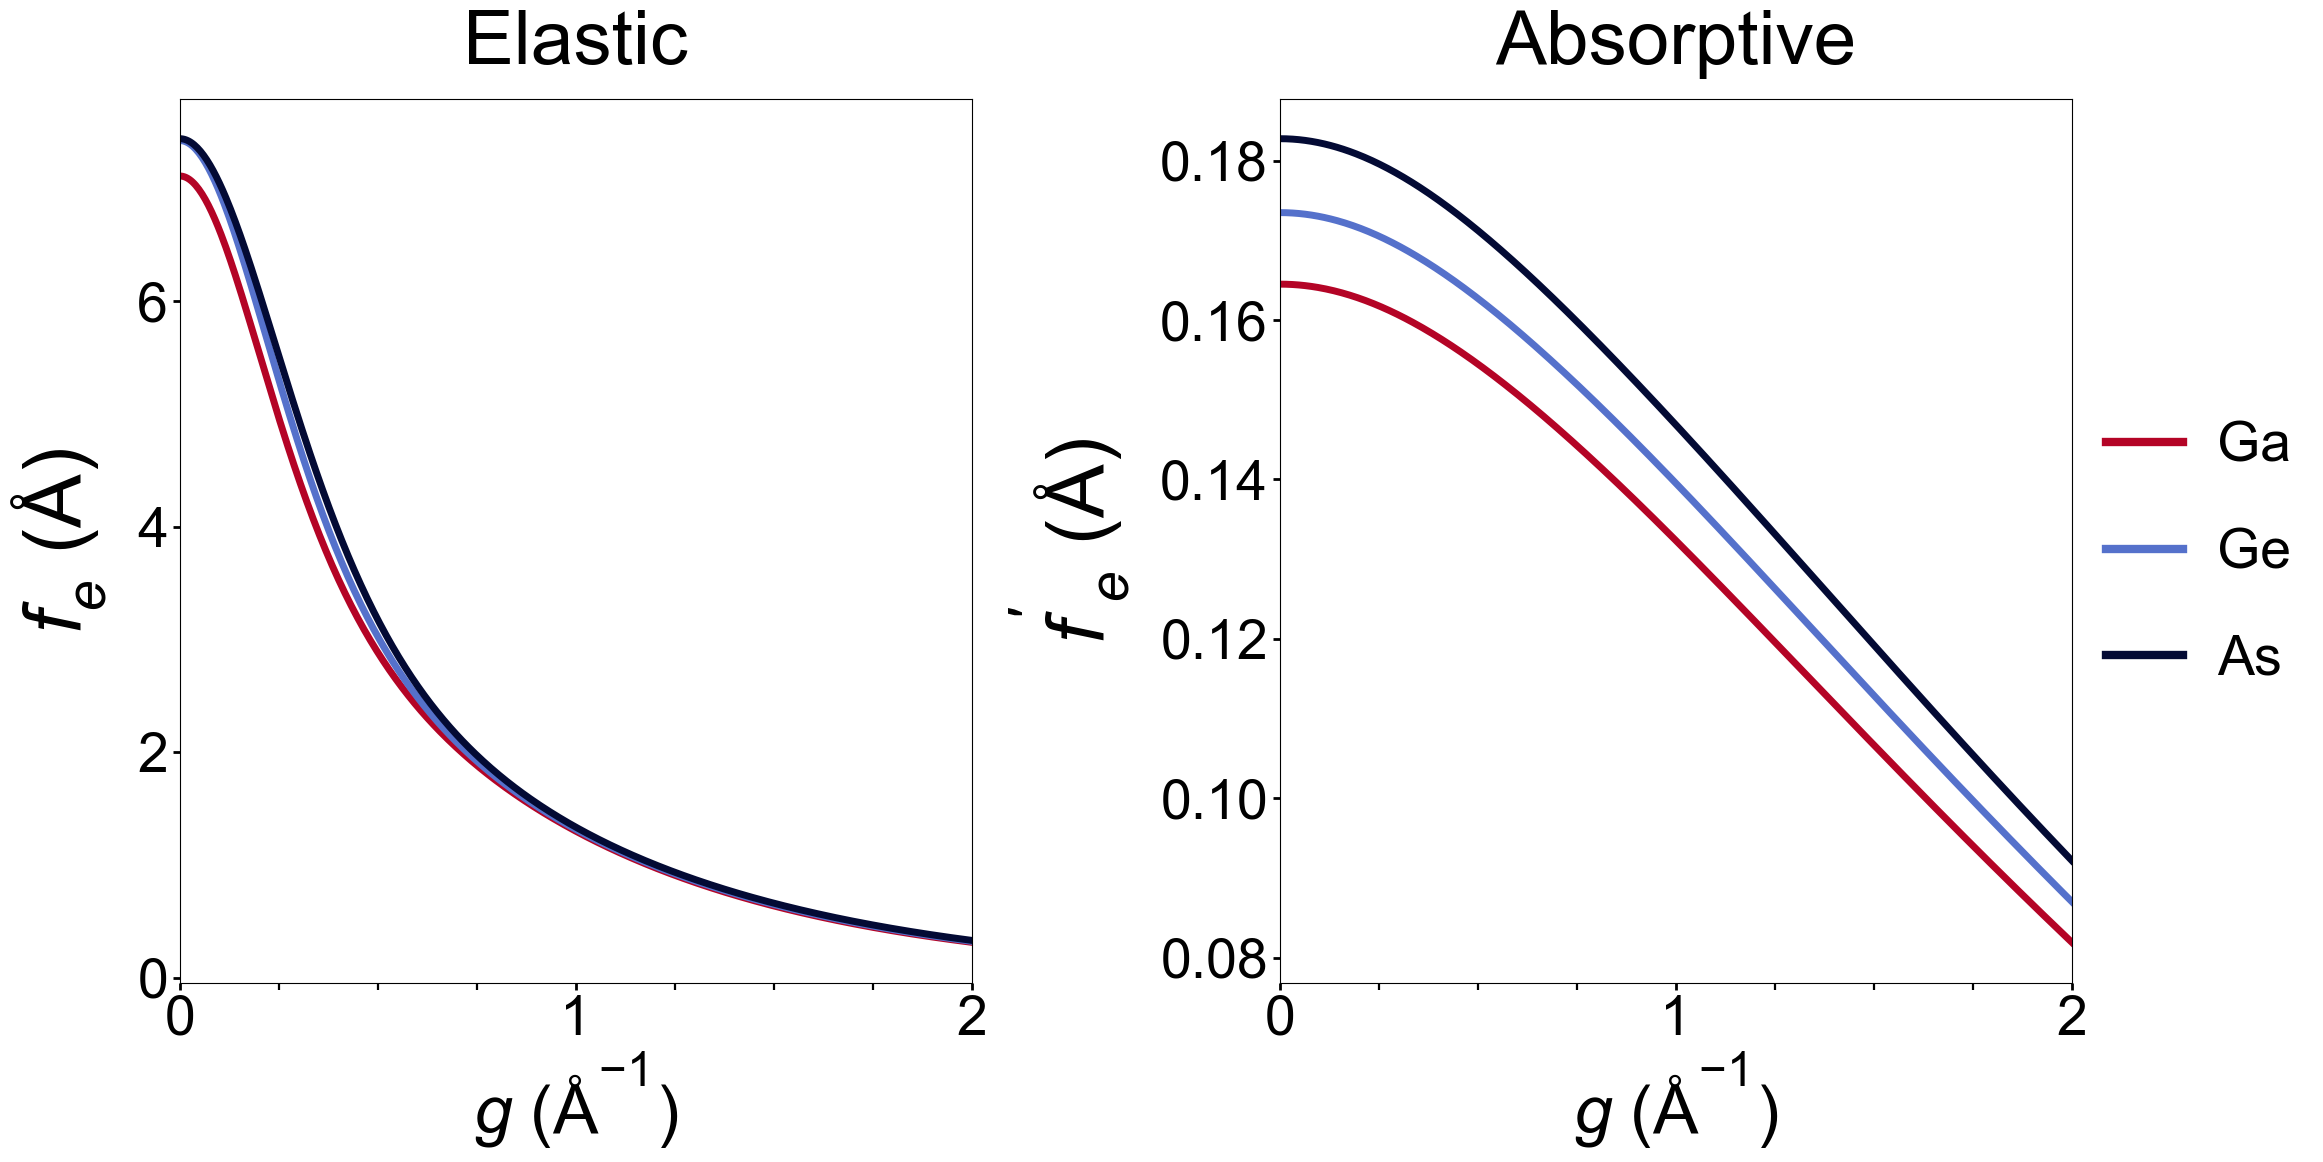

In [3]:
import sys
from pathlib import Path

project_root = Path(str(REPO_ROOT / "diffBloch_version_0.0.1")).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.constants import c, e, m_e

from abtem.parametrizations import validate_parametrization
from diffBloch.complex_scattering_factor import calc_complex_scattering_factors

plt.rcParams["font.family"] = "Arial"

Uiso = 0.0072621  # Angstrom^2
B = 8 * np.pi**2 * Uiso
print("B =", B)

energy = 200000  # eV
gamma = 1 + (e * energy) / (m_e * c**2)
velocity = c * np.sqrt(1 - 1 / gamma**2)

g = np.linspace(0, 2.0, 500)  # Angstrom^-1

elements = {
    "Ga": 31,
    "Ge": 32,
    "As": 33,
}

colors = {
    "Ga": "#b40426",
    "Ge": "#5571cb",
    "As": "#030a34",
}

parametrization = validate_parametrization("lobato")
dwf = np.exp(-2.0 * np.pi**2 * Uiso * g**2)

fig = plt.figure(figsize=(22, 13))

ax_elastic = fig.add_axes([0.075, 0.17, 0.36, 0.68])
ax_abs     = fig.add_axes([0.575, 0.17, 0.36, 0.68])

for label, Z in elements.items():
    f_elastic = parametrization.scattering_factor(Z)(g**2)
    f_elastic = np.asarray(f_elastic, dtype=float) * dwf

    # diffBloch/dynamical.py uses s = g/2 internally for absorptive factors
    f_abs = calc_complex_scattering_factors(g / 2, B, velocity, Z)
    f_abs = np.asarray(f_abs, dtype=float)

    ax_elastic.plot(g, f_elastic, linewidth=5, color=colors[label], label=label)
    ax_abs.plot(g, f_abs, linewidth=5, color=colors[label], label=label)

ax_elastic.set_xlabel(r"$g$ ($\mathrm{\AA^{-1}}$)", fontsize=49)
ax_abs.set_xlabel(r"$g$ ($\mathrm{\AA^{-1}}$)", fontsize=49)

ax_elastic.set_ylabel(r"$f_e$ ($\mathrm{\AA}$)", fontsize=58, labelpad=20)
ax_abs.set_ylabel(r"$f'_e$ ($\mathrm{\AA}$)", fontsize=58, labelpad=20)

ax_elastic.set_title("Elastic", fontsize=55, pad=25)
ax_abs.set_title("Absorptive", fontsize=55, pad=25)

for ax in [ax_elastic, ax_abs]:
    ax.set_xlim(0, 2.0)
    ax.set_xticks([0, 1, 2])
    ax.set_xticks(np.arange(0, 2.01, 0.25), minor=True)
    ax.tick_params(axis="both", which="major", labelsize=40, length=5, width=2)
    ax.tick_params(axis="both", which="minor", length=5, width=1.6)

legend_handles = [
    Line2D([0], [0], color=colors[label], linewidth=6)
    for label in elements
]
legend_labels = list(elements.keys())

fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.94, 0.5),
    borderaxespad=0.01,
    labelspacing=1.0,
    handlelength=1.4,
    handletextpad=0.6,
    fontsize=40,
    frameon=False,
)

plt.show()


In [4]:

def get_loss(loss_name):
    """
    Get loss function from loss name
    """
    loss_dict = {
        "rbragg_abs": rbragg_abs,
    }
    if loss_name not in loss_dict:
        raise ValueError(f"Loss name {loss_name} not found")
    return loss_dict[loss_name]


def rbragg_abs(sim_intensities, exp_intensities, sigmas=None):
    """
    Compute the Rbragg metric on the already-filtered intensity arrays.

    R = sum(|sqrt(I_pred) - sqrt(I_exp)|) / sum(sqrt(I_exp))

    Params:
    - sim_intensities: torch.tensor of predicted intensities
    - exp_intensities: torch.tensor of experimental intensities
    - sigmas: optional tensor kept for API compatibility; not used for filtering here

    Returns:
    - R(obs): torch.tensor of R(obs) value
    """
    if sigmas is None:
        sigmas = torch.ones_like(exp_intensities)

    sqrt_exp = exp_intensities.sqrt()
    sqrt_sim = sim_intensities.sqrt()
    num = torch.sum(torch.abs(sqrt_exp - sqrt_sim), dim=-1)
    denom = torch.sum(sqrt_exp, dim=-1)
    return num / denom

def initialize_scaling_factor(
    exp_intensities, simulated_intensities, sigmas, r_value_method="rbragg_abs"
    ):
    """
    Initialize scaling factor to minimize R value
    Params:
    - scaling_factor: scaling factor for each rotation
    - exp_intensities: experimental intensities
    - simulated_intensities: simulated intensities
    - sigmas: experimental sigmas
    - r_value_method: whether to use wRbragg, rbragg_abs, or rbragg_squared
    Returns:
    - scaling_factor: scaling factor for each rotation
    """
    start = 0.02
    end = 2
    num_points = 100
    grid_points = torch.linspace(start, end, num_points, device=exp_intensities.device)
    exp_sum = torch.sum(exp_intensities)
    sim_sum = torch.sum(simulated_intensities)
    scaled_intensities = (
        grid_points.view(-1, 1) * (exp_sum / sim_sum) * simulated_intensities
    )
    losses = get_loss(r_value_method)(scaled_intensities, exp_intensities, sigmas)
    min_value, min_idx = torch.min(losses, dim=0)
    scaling_factor = grid_points[min_idx]

    return scaling_factor, min_value


In [5]:

# --- Fixed material palette (one base color per material) ---
PALETTE = ["#3b4cc0", "#25d63c", "#b40426"]  # blue, green, red

def lighten_color(color, amount=0.5):
    """Lighten color by moving luminance toward 1 by `amount` in HLS space."""
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(h, 1 - amount * (1 - l), s)

def draw_grouped_legend(ax, legend_dict, start_y=0.95, dy=0.11, x0=0.03):
    """
    legend_dict = { "Material A": {rot1: color_shade1, rot2: color_shade2, ...}, ... }
    """
    y = start_y
    for material, rotmap in legend_dict.items():
        ax.text(x0, y, f"{material}", fontsize=37, fontweight="bold",
                transform=ax.transAxes, va="top")
        row_y = y - dy
        ax.text(x0, row_y, "Orientation", fontsize=35,
                transform=ax.transAxes, va="center")
        x1 = x0 + 0.25
        for idx, (_, color) in enumerate(rotmap.items(), start=1):
            ax.text(x1, row_y, f"●{idx}", fontsize=37,
                    transform=ax.transAxes, va="center", color=color)
            x1 += 0.055
        y -= 1.7 * dy    

In [6]:
# --- Compare paired intensity files (no_abs vs abs) ---
def parse_hkl_str(s: str):
    if not isinstance(s, str):
        return None
    s = s.strip().strip("()[]").replace(",", " ")
    parts = [p for p in s.split() if p]
    if len(parts) != 3:
        return None
    try:
        return tuple(int(p) for p in parts)
    except ValueError:
        return None


def _prepare_global_intensity_table(path, intensity_name):
    df = pd.read_csv(path)

    if "HKL" in df.columns:
        parsed = df["HKL"].apply(parse_hkl_str)
        df = df[parsed.notna()].copy()
        df[["h", "k", "l"]] = pd.DataFrame(parsed[parsed.notna()].tolist(), index=df.index)

    if not {"h", "k", "l"}.issubset(df.columns):
        raise KeyError(f"{path} needs either an HKL column or explicit h,k,l columns")

    if "Intensity" in df.columns:
        df = df.rename(columns={"Intensity": intensity_name})
    elif "intensity" in df.columns:
        df = df.rename(columns={"intensity": intensity_name})
    elif intensity_name not in df.columns:
        raise KeyError(f"{path} is missing an Intensity/intensity column")

    df[["h", "k", "l"]] = df[["h", "k", "l"]].astype(int)
    df[intensity_name] = pd.to_numeric(df[intensity_name], errors="coerce")

    keep_cols = ["h", "k", "l", intensity_name]
    if "G-vector Length" in df.columns:
        g_name = "G_no_abs" if intensity_name == "I_no_abs" else "G_abs"
        df = df.rename(columns={"G-vector Length": g_name})
        df[g_name] = pd.to_numeric(df[g_name], errors="coerce")
        keep_cols.append(g_name)

    return df[keep_cols].dropna()


def compare_and_compute_R(no_abs_csv, abs_csv, cutoff=1e-20):
    print(f"[LOAD] no_abs={no_abs_csv}, abs={abs_csv}")
    df_no_abs = _prepare_global_intensity_table(no_abs_csv, "I_no_abs")
    df_abs = _prepare_global_intensity_table(abs_csv, "I_abs")

    # Pair the same reflection between abs and no_abs. No cross-material HKL subset is enforced.
    df = pd.merge(df_no_abs, df_abs, on=["h", "k", "l"], how="inner")
    print(f"[INFO] After abs/no_abs HKL pairing: {df.shape}")

    before = len(df)
    df = df[(df["I_no_abs"] > cutoff) & (df["I_abs"] > cutoff)].copy()
    after = len(df)
    print(f"[FILTER] Applied intensity cutoff={cutoff}, kept {after}/{before} rows")

    if df.empty:
        print("[WARN] Empty dataframe after intensity filter, returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    exp_ints = torch.tensor(df["I_no_abs"].values, dtype=torch.float32)
    sim_ints = torch.tensor(df["I_abs"].values, dtype=torch.float32)
    if exp_ints.sum().item() == 0 or sim_ints.sum().item() == 0:
        print("[WARN] Zero or empty intensities, returning NaN")
        return float("nan"), pd.DataFrame(), float("nan")

    scale, R_global = initialize_scaling_factor(
        exp_intensities=exp_ints,
        simulated_intensities=sim_ints,
        sigmas=torch.ones_like(exp_ints),
        r_value_method="rbragg_abs"
    )
    print(f"[RESULT] Global R={R_global.item():.6f}, Scale={scale.item():.6f}")

    return R_global.item(), pd.DataFrame(), float("nan")


def _collect_intensity_file_pairs(folder, orientations=None):
    folder = Path(folder)
    files = [f for f in folder.glob("*intensities.csv") if f.is_file()]
    orient_map = {}

    for f in files:
        m_rot = re.search(r"rotation_(\d+)", f.name)
        m_thick = re.search(r"thickness_(\d+)", f.name)
        if not (m_rot and m_thick):
            continue

        rotation = int(m_rot.group(1))
        thickness = int(m_thick.group(1))
        if orientations and rotation not in orientations:
            continue

        if f.name.startswith("param_"):
            abs_type = "param"
        elif f.name.startswith("no_abs_"):
            abs_type = "no_abs"
        else:
            continue

        orient_map.setdefault(rotation, {}).setdefault(thickness, {})[abs_type] = f

    pairs = []
    for rot, thickmap in sorted(orient_map.items()):
        for thickness, pair in sorted(thickmap.items()):
            if "no_abs" in pair and "param" in pair:
                pairs.append({
                    "Rotation": rot,
                    "Thickness": thickness,
                    "no_abs": pair["no_abs"],
                    "param": pair["param"],
                })
    return pairs


def process_and_collect_global_only(folder, cutoff=1e-20, orientations=None):
    results = []
    for pair in _collect_intensity_file_pairs(folder, orientations=orientations):
        global_R, df_rvals_tilt, avg_R = compare_and_compute_R(
            no_abs_csv=pair["no_abs"],
            abs_csv=pair["param"],
            cutoff=cutoff,
        )
        results.append({
            "Rotation": pair["Rotation"],
            "Thickness": pair["Thickness"],
            "Global_R": global_R,
            "Avg_Tilt_R": avg_R,
            "Std_Tilt_R": df_rvals_tilt["R_value"].std(skipna=True) if not df_rvals_tilt.empty else float("nan"),
        })

    if not results:
        return pd.DataFrame(columns=["Rotation", "Thickness", "Global_R", "Avg_Tilt_R", "Std_Tilt_R"])
    return pd.DataFrame(results).sort_values(["Rotation", "Thickness"])


def _finite_xy(df_rot, y_column):
    x_nm = (df_rot["Thickness"] / 10.0).to_numpy(dtype=float)
    y = (100 * df_rot[y_column]).to_numpy(dtype=float)
    keep = np.isfinite(x_nm) & np.isfinite(y)
    return x_nm[keep].reshape(-1, 1), y[keep]


def plot_global_only(
    material_folders,
    cutoff=1e-20,
    save_summary=None,
    params=None,
    mode="global",
    use_shaded_errors=False,
):
    results_map = {}
    for material, meta in material_folders.items():
        folder = meta["folder"]
        orientations = meta.get("orientations", None)
        print(f"[info] {material}: using intensity cutoff={cutoff} per file pair")

        df = process_and_collect_global_only(
            folder,
            cutoff=cutoff,
            orientations=orientations,
        )
        results_map[material] = df
        if df.empty:
            print(f"[warn] No param/no_abs file pairs found in: {folder}")

    if all(df.empty for df in results_map.values()):
        return results_map

    fig, ax = plt.subplots(figsize=(12, 9))
    mats = list(results_map.keys())
    mat_base_color = {mat: PALETTE[i % len(PALETTE)] for i, mat in enumerate(mats)}
    legend_dict = {}

    for material, df in results_map.items():
        if df.empty:
            continue

        base_color = mat_base_color[material]
        rotations = sorted(df["Rotation"].unique())
        n_rot = len(rotations)
        legend_dict[material] = {}

        for j, rot in enumerate(rotations):
            frac = 0.3 + 0.7 * (j / max(1, n_rot - 1))
            color = lighten_color(base_color, amount=frac)
            legend_dict[material][rot] = color

            df_rot = df[df["Rotation"] == rot]

            if mode in ("tilt", "both"):
                x_nm, y = _finite_xy(df_rot, "Avg_Tilt_R")
                if len(y) == 0:
                    print(f"[tilt] {material} rot {rot}: no finite values to plot")
                else:
                    ax.scatter(x_nm, y, color=color, alpha=0.9, s=60, marker="s")
                    if len(y) >= 2:
                        model = LinearRegression().fit(x_nm, y)
                        print(f"[tilt] {material} rot {rot}: slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
                        x_fit = np.linspace(x_nm.min(), 250, 200).reshape(-1, 1)
                        ax.plot(x_fit, model.predict(x_fit), color=color, linewidth=3.0, linestyle="--", alpha=0.9)

            if mode in ("global", "both"):
                x_nm, y = _finite_xy(df_rot, "Global_R")
                if len(y) == 0:
                    print(f"[global] {material} rot {rot}: no finite values to plot")
                    continue

                ax.scatter(x_nm, y, color=color, s=60, marker="o")
                if len(y) >= 2:
                    model = LinearRegression().fit(x_nm, y)
                    print(f"[global] {material} rot {rot}: slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
                    x_fit = np.linspace(x_nm.min(), 250, 200).reshape(-1, 1)
                    ax.plot(x_fit, model.predict(x_fit), color=color, linewidth=3.5)

    ax.set_xticks([0, 100, 200])
    ax.set_xticks(np.arange(0, 251, 25), minor=True)
    ax.tick_params(axis="x", which="major", length=5, width=2.4)
    ax.tick_params(axis="x", which="minor", length=5, width=1.8)

    ax.set_yticks([0, 5, 10])
    ax.set_yticks(np.arange(0, 13, 1), minor=True)
    ax.tick_params(axis="y", which="major", length=5, width=2.4)
    ax.tick_params(axis="y", which="minor", length=5, width=1.8)

    ax.set_xlabel("Thickness (nm)", fontsize=45, labelpad=10)
    ax.set_ylabel(r"Residual ($R_1$) (%)", fontsize=45, labelpad=8)
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 8)
    ax.tick_params(axis="x", labelsize=45)
    ax.tick_params(axis="y", labelsize=45)
    draw_grouped_legend(ax, legend_dict)
    plt.tight_layout()
    plt.show()

    if save_summary:
        for label, df in results_map.items():
            out = Path(save_summary).with_name(f"{label}_{Path(save_summary).name}")
            df.to_csv(out, index=False)

    return results_map


[info] GaAs: using intensity cutoff=1e-20 per file pair
[LOAD] no_abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/no_abs_rotation_1_thickness_100_intensities.csv, abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/param_rotation_1_thickness_100_intensities.csv
[INFO] After abs/no_abs HKL pairing: (22, 7)
[FILTER] Applied intensity cutoff=1e-20, kept 22/22 rows
[RESULT] Global R=0.005091, Scale=1.000000
[LOAD] no_abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/no_abs_rotation_1_thickness_182_intensities.csv, abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/param_rotation_1_thickness_182_intensities.csv
[INFO] After abs/no_abs HKL pairing: (22, 7)
[FILTER] Applied intensity cutoff=1e-20, kept 22/22 rows
[RESULT] Global R=0.006341, Scale=1.000000
[LOAD] no_abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/no_abs_rotation_1_thickness_265_intensities.csv, abs=diffBloch_version_0.0.1/absorption/non_centro/GaAs/param_rotation_1_thickness_265_intensities.csv
[INFO]

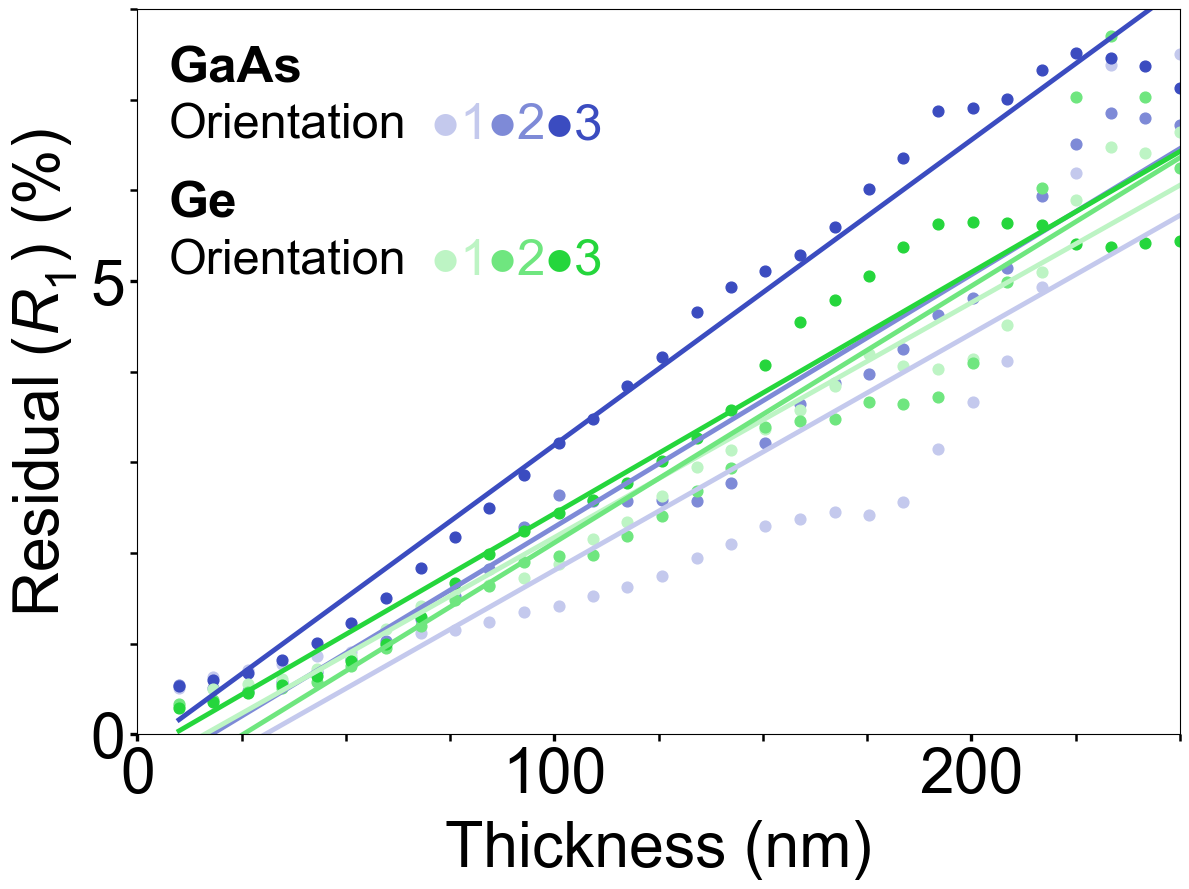

In [7]:
results = plot_global_only(
    {
        r"GaAs": {
            "folder": str(REPO_ROOT / "diffBloch_version_0.0.1/absorption/non_centro/GaAs"),
            "orientations": [1, 2, 3],
        },
        r"Ge": {
             "folder": str(REPO_ROOT / "diffBloch_version_0.0.1/absorption/non_centro/Ge"),
            "orientations": [1, 2, 3],
        },
    },
    mode="global",
)
